# REGRESIÓN LOGISTICA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


# OBJETIVO:
* ### ¿Como determinar si un pasajero sobrevivio o no segun sus variables independientes?

## 📈 Regresión Logística

La **regresión logística** es un algoritmo de clasificación que se utiliza para predecir la **probabilidad** de que una observación pertenezca a una de dos clases (binaria: 0 o 1). A diferencia de la regresión lineal, su salida no es continua, sino una probabilidad entre 0 y 1.

---

### 🔍 Fórmula General

Primero, se calcula una combinación lineal de las variables independientes:

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n
$$

Luego, esta combinación se transforma mediante la función **sigmoide** para obtener una probabilidad:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Donde:

- $\hat{y}$ es la probabilidad estimada de que la clase sea 1.  
- $e$ es la base del logaritmo natural.  
- $z$ es la salida de la regresión lineal.

---

### 📊 Interpretación

- Si $\hat{y} > 0.5$, se predice clase 1.  
- Si $\hat{y} \leq 0.5$, se predice clase 0.

---

## SIMPLIFICAMOS EL DATASET PARA PRUEBAS

In [3]:
cols = ['pclass','sex','age','fare']
df = df[cols + ['survived']].dropna()
df

,pclass,sex,age,fare,survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0
...,...,...,...,...,...
885,3,female,39.0,29.1250,0
886,2,male,27.0,13.0000,0
887,1,female,19.0,30.0000,1
889,1,male,26.0,30.0000,1


In [4]:
df.isnull().sum()

,0
pclass,0
sex,0
age,0
fare,0
survived,0


In [5]:
df.dtypes

,0
pclass,int64
sex,object
age,float64
fare,float64
survived,int64


# CODIFICAMOS VARIABLES SEX

In [6]:
df['sex'] = df['sex'].map({'male':0, 'female':1})
df

,pclass,sex,age,fare,survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0
...,...,...,...,...,...
885,3,1,39.0,29.1250,0
886,2,0,27.0,13.0000,0
887,1,1,19.0,30.0000,1
889,1,0,26.0,30.0000,1


In [7]:
df.dtypes

,0
pclass,int64
sex,int64
age,float64
fare,float64
survived,int64


# CORRELACIONES

In [8]:
corr_matrix = df.corr()
corr_result = corr_matrix['survived']
corr_result.sort_values(ascending=False)

,survived
survived,1.000000
sex,0.538826
fare,0.268189
age,-0.077221
pclass,-0.359653


<Axes: >

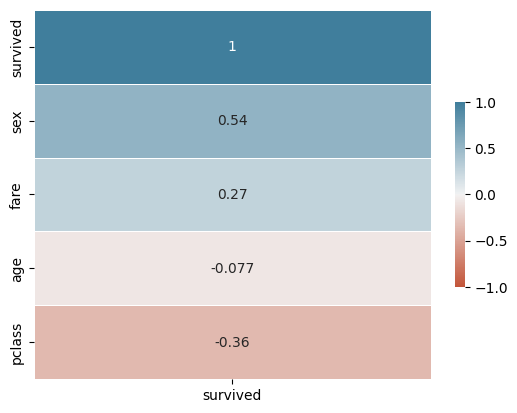

In [9]:
sns.heatmap(
    data=corr_result.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

# ENTRENAMOS UN MODELO DE CLASIFICACIÓN CON REGRESIÓN LOGISTICA

## PASO 1 - IDENTIFICAR VARIABLE X y y

In [11]:
X = df[cols]
y = df['survived']

## PASO 2 - DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## PASO 3 - ESCALAMIENTO DE DATOS

## EN ESTE CASO SOLO SE HACE A LA VARIABLE X porque Y es binario

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## PASO 4 - CREAMOS Y ENTRENAMOS EL MODELO

In [14]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

## PASO 5 - EVALUMOS EL MODELO

## ✅ ¿Qué es el Accuracy?

El **accuracy** (o exactitud) es una métrica utilizada en problemas de **clasificación** para medir qué tan bien un modelo predice las clases correctas.

### 📌 Definición
El accuracy representa el **porcentaje de predicciones correctas** que hizo el modelo sobre el total de predicciones.

### 📘 Fórmula

$[
Accuracy = \frac{\text{Número de predicciones correctas}}{\text{Total de predicciones}}
$]

### 🧠 Interpretación
- **1.0 (100%)** → El modelo acertó todas las predicciones.  
- **0.0 (0%)** → El modelo falló todas.  
- **Valores cercanos a 1** → Mejor desempeño.  
- **Valores cercanos a 0.5** → El modelo predice casi al azar (para 2 clases).

### 📊 Ejemplo
Si el modelo hizo 100 predicciones y acertó 87:

$[
Accuracy = \frac{87}{100} = 0.87
$]

➡️ El modelo tiene **87% de exactitud**.


In [16]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.74


## 📊 Matriz de Confusión

La **matriz de confusión** es una herramienta fundamental en la evaluación de modelos de **clasificación**.  
Permite visualizar claramente cómo se comportan las predicciones del modelo comparadas con los valores reales.

---

## 🧠 ¿Qué muestra?

Organiza las predicciones en una tabla que compara:

- **Filas** → Clases reales  
- **Columnas** → Clases predichas  

De esta forma podemos ver:
- Cuántas predicciones fueron correctas  
- Cuántas fueron incorrectas  
- En qué clase se confundió el modelo  

In [17]:
conf_matrix = confusion_matrix(y_test,y_pred)
conf_matrix

array([[68, 19],
       [18, 38]])

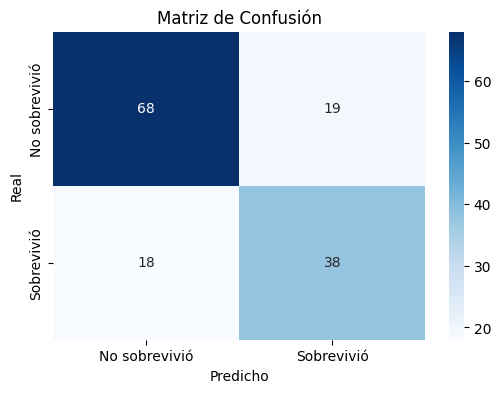

In [18]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()